# 🏙️ VoxCity 빠른 시작 가이드

**VoxCity**에 오신 것을 환영합니다 — 3D 복셀 기반 도시 모델을 생성하고 분석하기 위한 Python 패키지입니다.

이 노트북은 자동 데이터 소스 선택 기능을 통해 **5분 이내**에 설치 및 실행을 완료할 수 있도록 도와줍니다.

## 학습 내용
1. ✅ VoxCity 설치
2. ✅ 관심 지역 정의
3. ✅ 3D 도시 모델 자동 생성
4. ✅ 결과 시각화
5. ✅ 주요 형식으로 내보내기

## 📦 1단계: 설치

아래 셀을 실행하여 VoxCity를 설치하세요. 이미 설치된 경우 건너뜁니다.

In [1]:
# VoxCity 설치가 필요한 경우 주석을 해제하고 실행하세요
# !pip install voxcity

## 🌍 2단계: 관심 지역 정의

VoxCity는 **(경도, 위도)** 형식의 4개 모서리 좌표로 정의된 사각형 영역이 필요합니다.

다음은 **일본 도쿄**의 예시입니다. 본인의 좌표로 교체하여 사용하세요!

In [2]:
# 관심 지역을 사각형으로 정의합니다
# 형식: 각 모서리의 (경도, 위도)
rectangle_vertices = [
    (139.760, 35.680),  # 남서쪽 모서리
    (139.760, 35.690),  # 북서쪽 모서리
    (139.770, 35.690),  # 북동쪽 모서리
    (139.770, 35.680)   # 남동쪽 모서리
]

# 복셀 해상도를 미터 단위로 설정합니다
meshsize = 5  # 5m 해상도 - 작을수록 더 상세하지만 생성 속도는 느려집니다

print(f"정의된 영역: ~{abs(rectangle_vertices[2][0] - rectangle_vertices[0][0]) * 111320:.0f}m x {abs(rectangle_vertices[1][1] - rectangle_vertices[0][1]) * 111320:.0f}m")
print(f"복셀 크기: {meshsize}m")

정의된 영역: ~1113m x 1113m
복셀 크기: 5m


### 💡 팁: 대화형 영역 선택

대신 대화형 지도에서 사각형을 그리려면 다음 코드를 사용하세요:

```python
from voxcity.geoprocessor.draw import draw_rectangle_map_cityname

cityname = "Tokyo, Japan"
m, rectangle_vertices = draw_rectangle_map_cityname(cityname, zoom=15)
m  # Display the map, then draw a rectangle
```

## 🚀 3단계: 3D 도시 모델 생성

VoxCity가 해당 위치에 가장 적합한 데이터 소스를 **자동으로 선택**합니다!

In [3]:
import ee
ee.Authenticate()  # 화면에 뜨는 링크를 누르고 승인 토큰을 복사-붙여넣기 합니다.
ee.Initialize(project='ee-caiser0619')


INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, land_cover_source, canopy_height_source, dem_source, building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (139.7650, 35.6850): Japan
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenEarthMapJapan | https://www.open-earth-map.org/demo/Japan/leaflet.html
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=FABDEM | https://gee-community-catalog.org/projects/fabdem/
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.generator.grids | Creating Land Use Land Cover grid
 
INFO | voxcity.voxcity.generator.grids | Data source: OpenEarthMapJapan
INFO | voxcity.voxcity.generator.grids | 
OpenEarthMapJapan Land Cover Classes (sour

Composing image with dimensions: 1024x1024
GeoTIFF saved as 'output/quickstart\land_cover.tif' in Web Mercator projection (EPSG:3857).


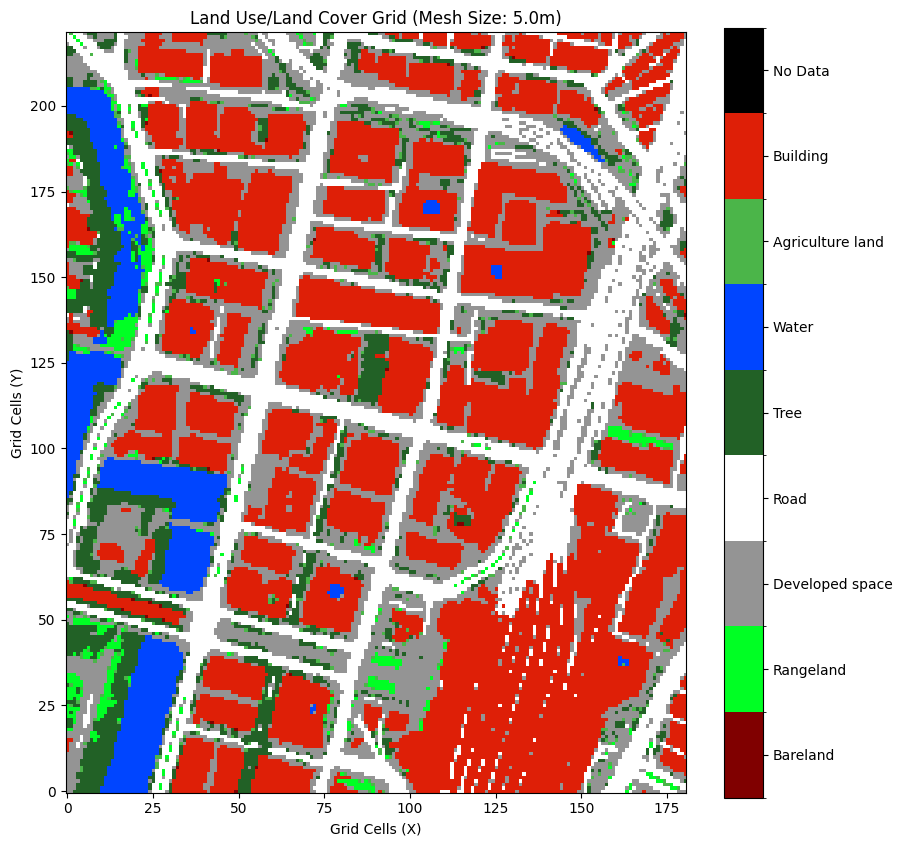

INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Complementary data source: None
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 240 of the total 351 building footprint from the base data source did not have height data.


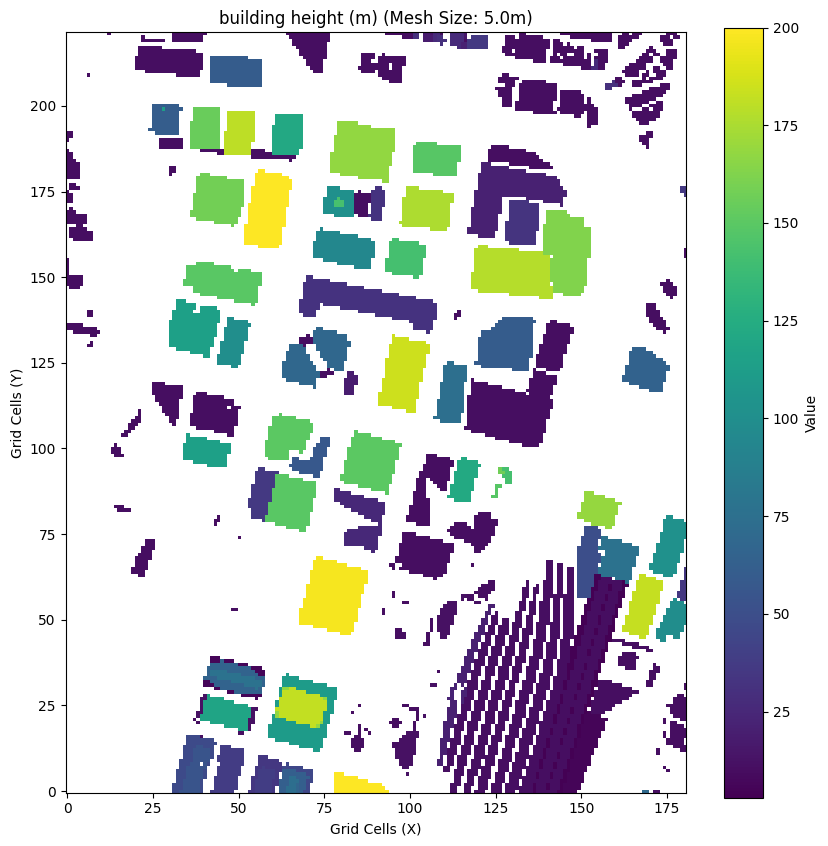

INFO | voxcity.voxcity.generator.grids | Creating Canopy Height grid
 
INFO | voxcity.voxcity.generator.grids | Data source: High Resolution 1m Global Canopy Height Maps


Generating URL ...
Please wait ...
Data downloaded to d:\repository\VoxCity\docs\examples\output\quickstart\canopy_height.tif


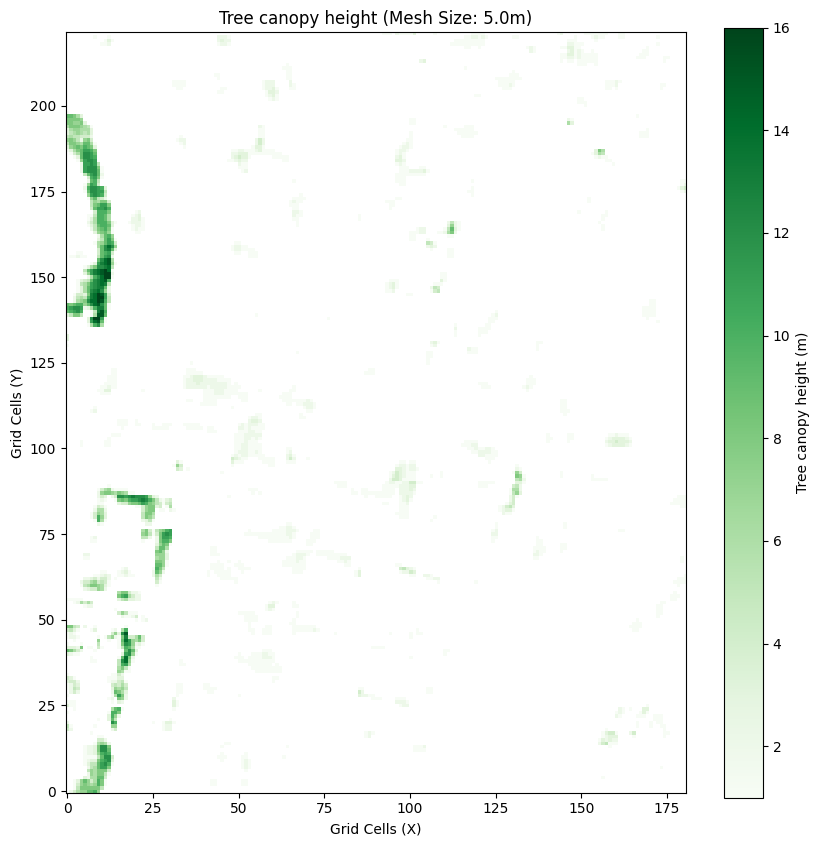

INFO | voxcity.voxcity.generator.grids | Creating Digital Elevation Model (DEM) grid
 
INFO | voxcity.voxcity.generator.grids | Data source: FABDEM


Generating URL ...
Please wait ...
Data downloaded to d:\repository\VoxCity\docs\examples\output\quickstart\dem.tif


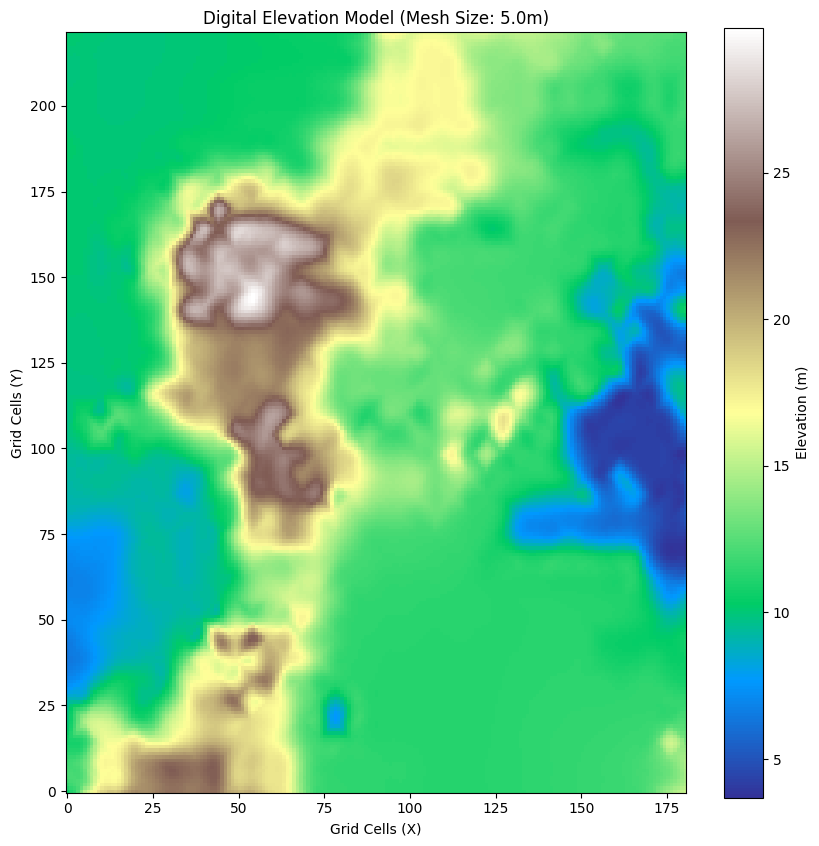

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/quickstart/voxcity.h5

✅ 도시 모델 생성 완료!
   복셀 그리드 형태: (222, 181, 45)
   (행 × 열 × 높이 레벨)


In [4]:
from voxcity.generator import get_voxcity

# Generate the city model with AUTO data source selection
city = get_voxcity(
    rectangle_vertices,
    meshsize=meshsize,
    output_dir='output/quickstart'  # Where to save intermediate files
)

# Show what we got
print(f"\n✅ 도시 모델 생성 완료!")
print(f"   복셀 그리드 형태: {city.voxels.classes.shape}")
print(f"   (행 × 열 × 높이 레벨)")

### VoxCity 객체에는 무엇이 들어있나요?

`city` 객체에는 여러 데이터 그리드가 포함되어 있습니다:

| 속성 | 설명 |
|-----------|-------------|
| `city.voxels.classes` | 3D 복셀 그리드 (0=공기, 1=지면, 2=나무, 3=건물) |
| `city.buildings.heights` | 2D 건물 높이 그리드 |
| `city.buildings.ids` | 2D 건물 ID 그리드 |
| `city.land_cover.classes` | 2D 토지 피복 분류 |
| `city.dem.elevation` | 2D 수치 표고 모델(DEM) |
| `city.tree_canopy.top` | 2D 수관(Canopy) 높이 그리드 |

In [5]:
# 데이터 요약 확인
import numpy as np

voxels = city.voxels.classes
print("복셀 통계:")
print(f"  공기 셀:       {np.sum(voxels == 0):,}")
print(f"  지면 셀:       {np.sum(voxels == 1):,}")
print(f"  나무 셀:       {np.sum(voxels == 2):,}")
print(f"  건물 셀:       {np.sum(voxels == 3):,}")

복셀 통계:
  공기 셀:       1,501,805
  지면 셀:       39
  나무 셀:       704
  건물 셀:       0


## 👁️ 4단계: 3D 모델 시각화

In [6]:
from voxcity.visualizer import visualize_voxcity

# 정적 시각화 (이미지로 저장)
visualize_voxcity(
    city,
    mode="static",  # 이미지의 경우 'static', 3D 뷰어의 경우 'interactive'
    output_directory="output/quickstart"
)

[('iso_front_right', 'output/quickstart/city_view_iso_front_right.png'),
 ('iso_front_left', 'output/quickstart/city_view_iso_front_left.png'),
 ('iso_back_right', 'output/quickstart/city_view_iso_back_right.png'),
 ('iso_back_left', 'output/quickstart/city_view_iso_back_left.png'),
 ('xy_top', 'output/quickstart/city_view_xy_top.png'),
 ('yz_right', 'output/quickstart/city_view_yz_right.png'),
 ('xz_front', 'output/quickstart/city_view_xz_front.png'),
 ('yz_left', 'output/quickstart/city_view_yz_left.png'),
 ('xz_back', 'output/quickstart/city_view_xz_back.png')]

### 대화형 3D 시각화

회전 및 확대/축소가 가능한 대화형 뷰를 보려면:

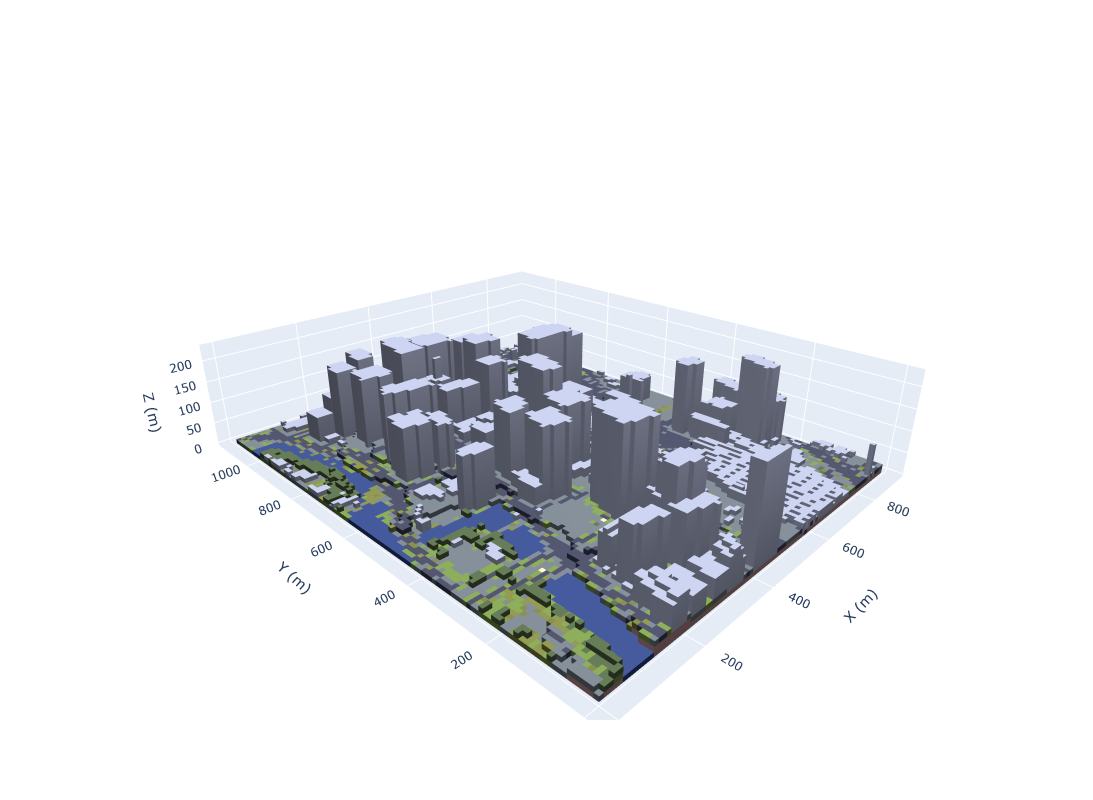

In [7]:
# Plotly를 사용한 대화형 시각화
# (Plotly가 필요합니다: pip install plotly)
fig = visualize_voxcity(city, mode="interactive", show=False, return_fig=True)
fig.show()

## 💾 5단계: 모델 내보내기

VoxCity는 다양한 용도에 맞는 여러 내보내기 형식을 지원합니다.

In [8]:
# OBJ로 내보내기 (Blender, Rhino, 3D 뷰어용)
from voxcity.exporter.obj import export_obj

export_obj(city, output_dir='output/quickstart', file_name='my_city')
print("✅ 내보내기 완료: output/quickstart/my_city.obj")

INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/quickstart with the base name "my_city".


✅ 내보내기 완료: output/quickstart/my_city.obj


In [9]:
# MagicaVoxel VOX 형식으로 내보내기 (복셀 아트 편집기용)
from voxcity.exporter.magicavoxel import export_magicavoxel_vox

export_magicavoxel_vox(city, "output/quickstart")
print("✅ 내보내기 완료: output/quickstart/voxcity.vox")

INFO | voxcity.voxcity.exporter.magicavoxel | Chunk 0_0_0 saved as output/quickstart/chunk_0_0_0.vox
INFO | voxcity.voxcity.exporter.magicavoxel | Shape: (181, 222, 45)
INFO | voxcity.voxcity.exporter.magicavoxel | 	vox files was successfully exported in output/quickstart


✅ 내보내기 완료: output/quickstart/voxcity.vox


In [10]:
# 나중에 사용하기 위해 VoxCity 객체 저장/불러오기
from voxcity.generator import save_voxcity, load_voxcity

save_voxcity('output/quickstart/city.pkl', city)
print("✅ 도시 객체 저장 완료")

# 나중에 다시 불러올 때:
# city = load_voxcity('output/quickstart/city.pkl')

INFO | voxcity.voxcity.io | Voxcity data saved to output/quickstart/city.pkl


✅ 도시 객체 저장 완료


## 🎉 완료되었습니다!

다음을 성공적으로 완료했습니다:
- 3D 복셀 도시 모델 생성
- 2D 및 3D 시각화
- 여러 형식으로 내보내기

## 다음 단계는?

다른 튜토리얼에서 더 고급 기능들을 살펴보세요:

| 노트북 | 설명 |
|----------|-------------|
| `demo_basic.ipynb` | 모든 데이터 소스 및 옵션에 대한 전체 가이드 |
| `demo_view.ipynb` | Green View Index(GVI) 및 Sky View Index(SVI) 분석 |
| `demo_solar.ipynb` | 태양 복사 에너지 시뮬레이션 |
| `demo_landmark.ipynb` | 랜드마크 가시성 분석 |
| `demo_3d_visualization.ipynb` | 고급 3D 시각화 옵션 |
| `demo_envi-met.ipynb` | ENVI-met CFD 시뮬레이션용 내보내기 |